# F1 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F1 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F1 (2D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 1
N_DIMS = 2
N_INITIAL = 10
WEEK = 10
USE_LOG_SCALE = True  # F1 only
DATA_DIR = '../../data/f1/'

## Step 1 — Load Data

In [3]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F1 — Week 10 Data Summary
  Input dimensions:  2
  Total samples:     20
  Initial samples:   10
  Submissions:       10
  Input shape:       (20, 2)
  Output shape:      (20,)
  Best output:       7.71088e-16
  Worst output:      -0.00360606

Sample | x1 | x2 | y
-------------------------------------------------
   1(init) | 0.319404 | 0.762959 | 1.32268e-79
   2(init) | 0.574329 | 0.879898 | 1.03308e-46
   3(init) | 0.731024 | 0.733000 | 7.71088e-16
   4(init) | 0.840353 | 0.264732 | 3.34177e-124
   5(init) | 0.650114 | 0.681526 | -0.00360606
   6(init) | 0.410437 | 0.147554 | -2.15925e-54
   7(init) | 0.312691 | 0.078723 | -2.08909e-91
   8(init) | 0.683418 | 0.861057 | 2.535e-40
   9(init) | 0.082507 | 0.403488 | 3.60677e-81
  10(init) | 0.883890 | 0.582254 | 6.22986e-48
  11( wk3) | 0.448979 | 0.142857 | 2.31408e-56
  12( wk4) | 0.708964 | 0.494269 | -1.15988e-17
  13( wk5) | 0.986481 | 0.986619 | 4.9777e-180
  14( wk6) | 0.060194 | 0.333985 | 2.84272e-97
  15( wk7) | 0.740501 | 0

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples. F1 uses a **logarithmic y-axis** since outputs span many orders of magnitude. Non-positive values are clamped to a small epsilon before computing log.

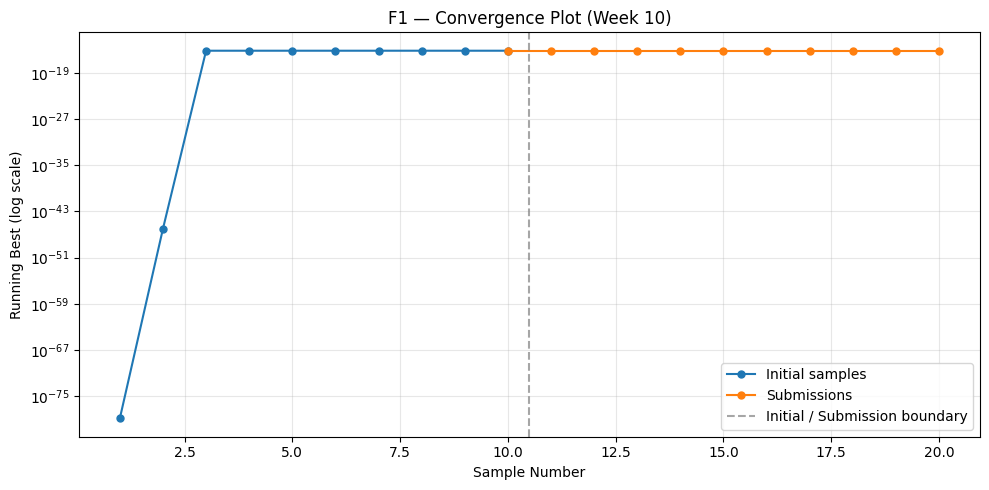

In [4]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

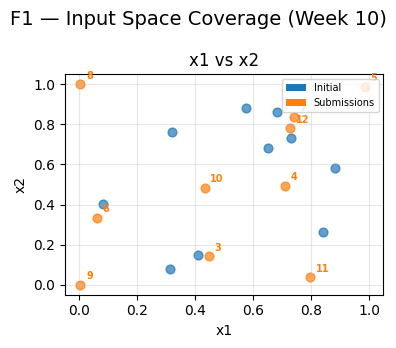

In [5]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: Hurdle Model — LogisticRegression classifier for P(y > 0) + RandomForest regressor on log(y) | y > 0
- **Acquisition**: Weighted UCB with κ = 0.5, prioritising exploitation
- **Key hyperparameters**: C=1.0, n_estimators=100, max_depth=3, 20k random candidates

### Performance Summary

In [6]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     7.71088e-16
Best value (final):       7.71088e-16
Improvements:             0/10
Max consecutive no-improve: 10
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |    2.31408e-56 |    7.71088e-16 | ✗
   4 |   -1.15988e-17 |    7.71088e-16 | ✗
   5 |    4.9777e-180 |    7.71088e-16 | ✗
   6 |    2.84272e-97 |    7.71088e-16 | ✗
   7 |    1.01873e-40 |    7.71088e-16 | ✗
   8 |              0 |    7.71088e-16 | ✗
   9 |   1.87428e-245 |    7.71088e-16 | ✗
  10 |    -0.00109123 |    7.71088e-16 | ✗
  11 |   6.93628e-202 |    7.71088e-16 | ✗
  12 |   -1.54765e-23 |    7.71088e-16 | ✗


### Evaluation

F1 has shown **persistent stalling** across all 10 submission rounds with **0 improvements** over the initial best. All submitted outputs are near-zero or negative, while the initial best is already extremely small (7.71e-16). The Hurdle Model + Weighted UCB approach has not been able to find regions with higher output values.

Key observations:
- The best value remains at the initial best of ~7.71e-16 — essentially zero on any practical scale
- All 10 submissions failed to improve, indicating the surrogate is unable to identify promising regions
- The pair plot shows submission points are scattered but have not discovered any high-output regions
- The function appears to have extremely localised peaks that the current exploration strategy cannot find

**Stalling status**: YES — 10 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

Given the persistent stalling of the current Hurdle Model + Weighted UCB (κ=0.5) approach, the following changes are recommended:

1. **Switch surrogate from Hurdle Model to SFGP with Matérn-2.5 ARD** — The Hurdle Model with RF regressor may lack the smoothness assumptions needed to interpolate between the sparse near-zero observations. A GP can provide uncertainty estimates that directly drive exploration via the acquisition function.

2. **Use qLogNEI instead of Weighted UCB** — The current UCB with κ=0.5 is in exploitation mode, but there is nothing to exploit (best is ~1e-16). Switch to Noisy Expected Improvement which naturally balances exploration and exploitation based on posterior uncertainty.

3. **Increase exploration aggressiveness** — Set q=4 to propose multiple candidates per round, using distance-based selection to ensure spatial diversity. The function clearly has extremely localised optima that require broader coverage.

4. **Apply log transform to outputs** — Since F1 outputs span many orders of magnitude, fitting the GP on log(max(y, ε)) will provide a better-conditioned posterior and more meaningful uncertainty estimates.

5. **Consider Latin Hypercube restart** — After 10 failed submissions, it may be worth seeding the acquisition optimisation with a space-filling design (e.g., 10,000 Sobol points) to ensure the entire [0,1]² domain is considered, rather than relying on the surrogate's posterior which may have collapsed.

**Priority**: HIGH — F1 has the worst performance of all 8 functions and has shown zero improvement across all submissions.